In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("/content/AirQualityUCI.csv", sep=';')
print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

         Date      Time CO(GT)  PT08.S1(CO)  NMHC(GT) C6H6(GT)  PT08.S2(NMHC)  \
0  10/03/2004  18.00.00    2,6       1360.0     150.0     11,9         1046.0   
1  10/03/2004  19.00.00      2       1292.0     112.0      9,4          955.0   
2  10/03/2004  20.00.00    2,2       1402.0      88.0      9,0          939.0   
3  10/03/2004  21.00.00    2,2       1376.0      80.0      9,2          948.0   
4  10/03/2004  22.00.00    1,6       1272.0      51.0      6,5          836.0   

   NOx(GT)  PT08.S3(NOx)  NO2(GT)  PT08.S4(NO2)  PT08.S5(O3)     T    RH  \
0    166.0        1056.0    113.0        1692.0       1268.0  13,6  48,9   
1    103.0        1174.0     92.0        1559.0        972.0  13,3  47,7   
2    131.0        1140.0    114.0        1555.0       1074.0  11,9  54,0   
3    172.0        1092.0    122.0        1584.0       1203.0  11,0  60,0   
4    131.0        1205.0    116.0        1490.0       1110.0  11,2  59,6   

       AH  Unnamed: 15  Unnamed: 16  
0  0,7578         

In [4]:
df.drop(columns=['Unnamed: 15', 'Unnamed: 16'], inplace=True)
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing values after handling:")
print(df.isnull().sum())


Missing values after handling:
Date             114
Time               0
CO(GT)             0
PT08.S1(CO)        0
NMHC(GT)           0
C6H6(GT)           0
PT08.S2(NMHC)      0
NOx(GT)            0
PT08.S3(NOx)       0
NO2(GT)            0
PT08.S4(NO2)       0
PT08.S5(O3)        0
T                  0
RH                 0
AH                 0
dtype: int64


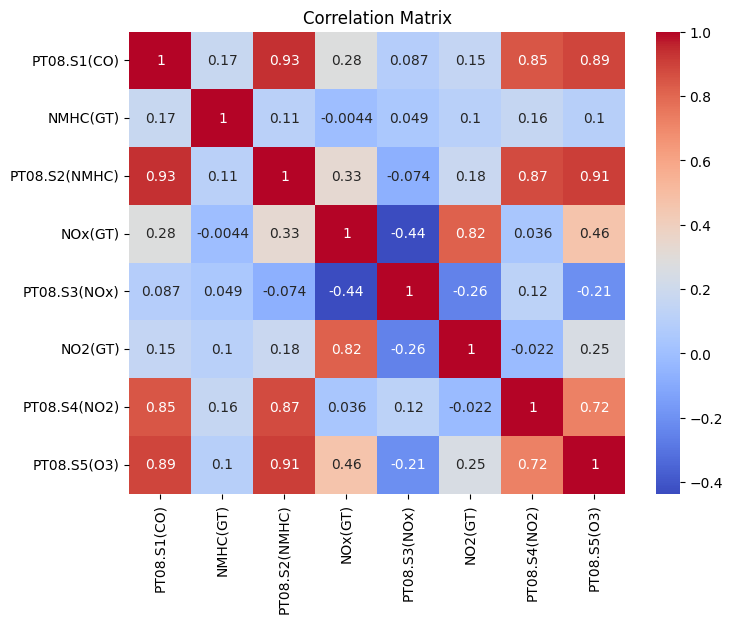

In [5]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [7]:
numeric_cols = [
    'CO(GT)', 'PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)',
    'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)',
    'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)',
    'T', 'RH', 'AH'
]

for col in numeric_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '.', regex=False)   # 7,8 → 7.8
    )
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [8]:
X = df[['PT08.S1(CO)', 'NMHC(GT)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']]
y = df['CO(GT)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [10]:
pred = model.predict(X_test)

In [11]:
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R² Score:", r2_score(y_test, pred))

MAE: 23.08450863192817
RMSE: 46.23847455388702
R² Score: 0.6371111930984388


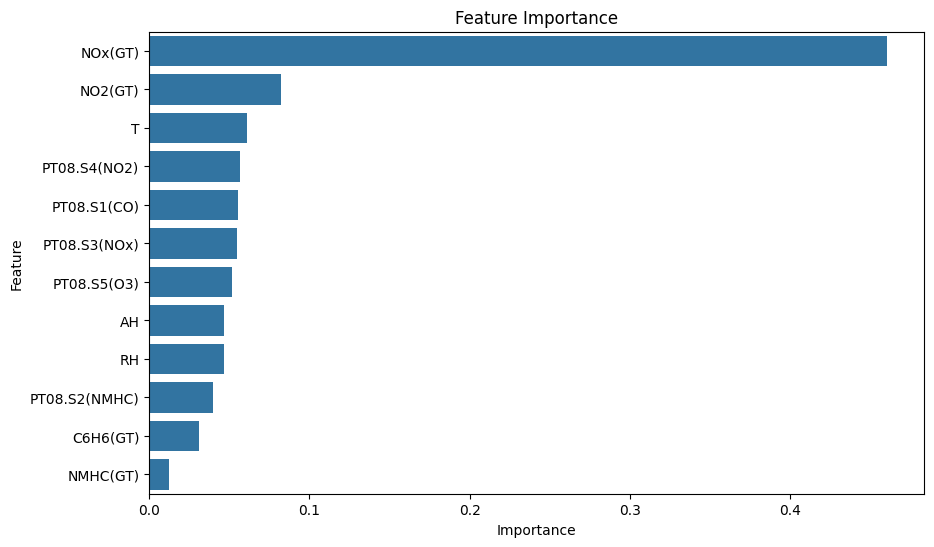

In [12]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importance, x="Importance", y="Feature")
plt.title("Feature Importance")
plt.show()

In [13]:
new_data = np.array([[
    1360,   # PT08.S1(CO)
    150,    # NMHC(GT)
    11.9,   # C6H6(GT)
    1046,   # PT08.S2(NMHC)
    166,    # NOx(GT)
    1056,   # PT08.S3(NOx)
    113,    # NO2(GT)
    1692,   # PT08.S4(NO2)
    1268,   # PT08.S5(O3)
    13.6,   # Temperature (T)
    48.9,   # Relative Humidity (RH)
    0.7578  # Absolute Humidity (AH)
]])

new_data_scaled = scaler.transform(new_data)
prediction = model.predict(new_data_scaled)
print(f"Predicted CO(GT): {prediction[0]:.2f} mg/m³")

Predicted CO(GT): 2.63 mg/m³


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


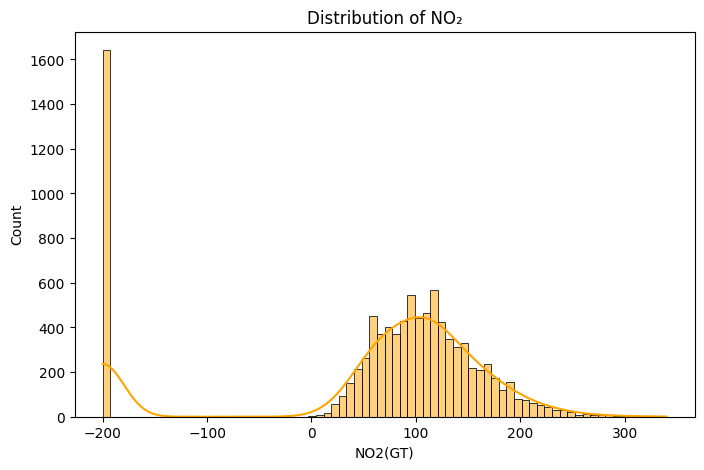

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['NO2(GT)'],
    kde=True,
    color="orange"
)

plt.title("Distribution of NO₂")
plt.show()

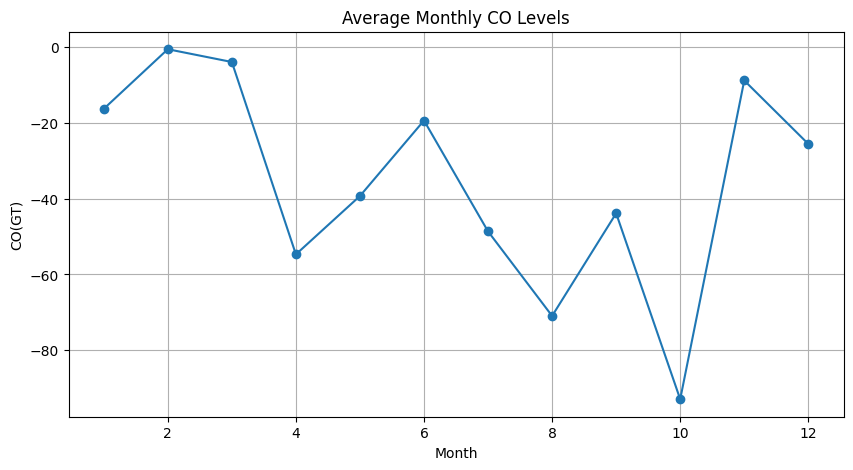

In [15]:
df['Month'] = df['Date'].dt.month
monthly = df.groupby('Month')['CO(GT)'].mean()
plt.figure(figsize=(10,5))
monthly.plot(marker='o')
plt.title("Average Monthly CO Levels")
plt.xlabel("Month")
plt.ylabel("CO(GT)")
plt.grid(True)
plt.show()